# The Setup, Model Definition, and Training Scripts

**SETUP**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! uv pip install pytorch_brain -q

# We use uv for the installation here, which seems to work better with google colab.
# Although UV is awesome and we highly recommend it, you could install it with vanilla pip
# in your local environments

**Run the block below to load utility functions.**

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import warnings
import logging
from torch_brain.utils import seed_everything

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)


def move_to_gpu(data, device):
    """
    Recursively moves tensors (or collections of tensors) to the given device.
    """
    if isinstance(data, torch.Tensor):
        return data.to(device)
    elif isinstance(data, dict):
        return {k: move_to_gpu(v, device) for k, v in data.items()}
    elif isinstance(data, list):
        return [move_to_gpu(elem, device) for elem in data]
    else:
        return data


def bin_spikes(spikes, num_units, bin_size, right=True, num_bins=None):
    """
    Bins spike timestamps into a 2D array: [num_units x num_bins].
    """
    rate = 1 / bin_size  # avoid precision issues
    binned_spikes = np.zeros((num_units, num_bins))
    bin_index = np.floor((spikes.timestamps) * rate).astype(int)
    np.add.at(binned_spikes, (spikes.unit_index, bin_index), 1)
    return binned_spikes


def r2_score(y_pred, y_true):
    # Compute total sum of squares (variance of the true values)
    y_true_mean = torch.mean(y_true, dim=0, keepdim=True)
    ss_total = torch.sum((y_true - y_true_mean) ** 2)

    # Compute residual sum of squares
    ss_res = torch.sum((y_true - y_pred) ** 2)

    # Compute R^2
    r2 = 1 - ss_res / ss_total

    return r2


def compute_r2(dataloader, model):
    # Compute R2 score over the entire dataset
    total_target = []
    total_pred = []
    for batch in dataloader:
        batch = move_to_gpu(batch, device)
        pred = model(**batch["model_inputs"])
        target = batch["target_values"]

        # Store target and pred for visualization
        mask = torch.ones_like(target, dtype=torch.bool)
        if "output_mask" in batch["model_inputs"]:
            mask = batch["model_inputs"]["output_mask"]
        total_target.append(target[mask])
        total_pred.append(pred[mask])

    # Concatenate all batch outputs
    total_target = torch.cat(total_target)
    total_pred = torch.cat(total_pred)

    # Compute the R2 score
    r2 = r2_score(total_pred.flatten(), total_target.flatten())

    return r2.item(), total_target, total_pred


def print_model(model: torch.nn.Module):
    """
    Prints a summary of the model architecture and parameter count.
    """
    model_str = str(model).split('\n')
    print("\nModel:")
    print('\n'.join(model_str[:5]))
    print("...")
    print('\n'.join(model_str[-min(5, len(model_str)):]))
    num_params = sum(p.numel() for p in model.parameters())
    if num_params > 1e9:
        param_str = f"{num_params/1e9:.1f}G"
    elif num_params > 1e6:
        param_str = f"{num_params/1e6:.1f}M"
    else:
        param_str = f"{num_params/1e3:.1f}K"
    print(f"\nNumber of parameters: {param_str}\n")


def plot_training_curves(r2_log, loss_log):
    """
    Plots the training curves: training loss and validation R2 score.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(np.linspace(0, len(loss_log), len(loss_log)), loss_log)
    plt.title("Training Loss")
    plt.xlabel("Training Steps")
    plt.ylabel("MSE Loss")
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.plot(r2_log)
    plt.title("Validation R2")
    plt.xlabel("Epochs")
    plt.ylabel("R2 Score")
    plt.grid()
    plt.tight_layout()
    plt.show()


def generate_sinusoidal_position_embs(num_timesteps, dim):
    position = torch.arange(num_timesteps).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2) * (-np.log(10000.0) / dim))
    pe = torch.empty(num_timesteps, dim)
    pe[:, 0:dim // 2] = torch.sin(position * div_term)
    pe[:, dim//2:] = torch.cos(position * div_term)
    return pe


def load_pretrained(ckpt_path, model):
    print("Loading pretrained model...")
    checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    # poyo is pretrained using lightning, so model weights are prefixed with "model."
    state_dict = {k.replace("model.", ""): v for k, v in checkpoint["state_dict"].items()}
    model.load_state_dict(state_dict)
    print("Done!")
    return model


def reinit_vocab(emb_module, vocab):
    emb_module.extend_vocab(vocab)
    emb_module.subset_vocab(vocab)


def get_dataset_config(brainset, sessions):
    brainset_norms = {
        "perich_miller_population_2018": {
            "mean": 0.0,
            "std": 20.0
        }
    }

    config = f"""
    - selection:
      - brainset: {brainset}
        sessions:"""
    if type(sessions) is not list:
        sessions = [sessions]
    for session in sessions:
        config += f"""
          - {session}"""
    config += f"""
      config:
        readout:
          readout_id: cursor_velocity_2d
          normalize_mean: {brainset_norms[brainset]["mean"]}
          normalize_std: {brainset_norms[brainset]["std"]}
          metrics:
            - metric:
                _target_: torchmetrics.R2Score
    """

    config = OmegaConf.create(config)

    return config

/usr/local/lib/python3.12/dist-packages/temporaldata/temporaldata.py:1209: SyntaxWarning: invalid escape sequence '\*'
  multi-dimensional (2d, 3d, ..., nd) arrays with shape (N, \*).
/usr/local/lib/python3.12/dist-packages/einops/einops.py:737: SyntaxWarning: invalid escape sequence '\s'
  \sum_{c, d, g} x[a, b, c] * y[c, b, d] * z[a, g, k]


DATA LOADING


In [ ]:
from torch_brain.data import Dataset, collate, chain
from torch_brain.data.sampler import RandomFixedWindowSampler, SequentialFixedWindowSampler
from torch.utils.data import DataLoader

def get_train_val_loaders(recording_id=None, cfg=None, batch_size=32, seed=0):
    """Sets up train and validation Datasets, Samplers, and DataLoaders
    """

    # -- Train --
    train_dataset = Dataset(
        root="data",                # root directory where .h5 files are found
        recording_id=recording_id,  # you either specify a single recording ID
        config=cfg,                 # or a config for multi-session training / more complex configs
        split="train",
    )
    # We use a random sampler to improve generalization during training
    train_sampling_intervals = train_dataset.get_sampling_intervals()
    train_sampler = RandomFixedWindowSampler(
        sampling_intervals=train_sampling_intervals,
        window_length=1.0,          # context window of samples
        generator=torch.Generator().manual_seed(seed),
    )
    # Finally combine them in a dataloader
    train_loader = DataLoader(
        dataset=train_dataset,      # dataset
        sampler=train_sampler,      # sampler
        batch_size=batch_size,      # num of samples per batch
        collate_fn=collate,         # the collator
        num_workers=4,              # data sample processing (slicing, transforms, tokenization) happens in parallel; this sets the amount of that parallelization
        pin_memory=True,
    )

    # -- Validation --
    val_dataset = Dataset(
        root="data",
        recording_id=recording_id,
        config=cfg,
        split="valid",
    )
    # For validation we don't randomize samples for reproducibility
    val_sampling_intervals = val_dataset.get_sampling_intervals()
    val_sampler = SequentialFixedWindowSampler(
        sampling_intervals=val_sampling_intervals,
        window_length=1.0,
    )
    # Combine them in a dataloader
    val_loader = DataLoader(
        dataset=val_dataset,
        sampler=val_sampler,
        batch_size=batch_size,
        collate_fn=collate,
        num_workers=4,
        pin_memory=True,
    )

    train_dataset.disable_data_leakage_check()
    val_dataset.disable_data_leakage_check()

    return train_dataset, train_loader, val_dataset, val_loader

Downloading a Session

In [ ]:
! mkdir -p data/perich_miller_population_2018
! gdown 1W--Sm_BcphEC2snoF4zwPdHkkYGgAaUw -O data/perich_miller_population_2018/t_20130819_center_out_reaching.h5

Downloading...
From: https://drive.google.com/uc?id=1W--Sm_BcphEC2snoF4zwPdHkkYGgAaUw
To: /content/data/perich_miller_population_2018/t_20130819_center_out_reaching.h5
100% 9.88M/9.88M [00:00<00:00, 79.8MB/s]


MLP

In [ ]:
import torch.nn as nn

class MLPNeuralDecoder(nn.Module):
    def __init__(self, num_units, bin_size, sequence_length, output_dim, hidden_dim):
        """Initialize the neural net layers."""
        super().__init__()

        self.num_timesteps = int(sequence_length / bin_size)
        self.bin_size = bin_size

        self.net = nn.Sequential(
            nn.Linear(self.num_timesteps * num_units, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim * self.num_timesteps),
        )

    def forward(self, x):
        """Produces predictions from a binned spiketrain.
        This is pure PyTorch code.

        Shape of x: (B, T, N)
        """

        x = x.flatten(1)                          # (B, T, N)    -> (B, T*N)
        x = self.net(x)                           # (B, T*N)     -> (B, T*D_out)
        x = x.reshape(-1, self.num_timesteps, 2)  # (B, T*D_out) -> (B, T, D_out)
        return x

    def tokenize(self, data):
        """tokenizes a data sample, which is a sliced Data object"""

        # A. Extract and bin neural activity (data.spikes)
        spikes = data.spikes
        x = bin_spikes(
            spikes=spikes,
            num_units=len(data.units),
            bin_size=self.bin_size,
            num_bins=self.num_timesteps
        ).T
        # Final shape of x here is (timestamps, num_neurons)

        # B. Extract the corresponding cursor velocity, which will act as targets
        #    for training the MLP.
        y = data.cursor.vel
        # Final shape of y is (timestamps x 2)
        # Note that in this example we have choosen the bin size to match the
        # sampling rate of the recorded cursor velocity.

        # Finally, we output the "tokenized" data in the form of a dictionary.
        data_dict = {
            "model_inputs": {
                "x": torch.tensor(x, dtype=torch.float32),
                # Models in torch_brain typically follow the convention that
                # fields that are input to model.forward() are stored in
                # "model_inputs". Although you are free to deviate from this,
                # we have found that this convention generally produces cleaner
                # training loops.
            },
            "target_values": torch.tensor(y, dtype=torch.float32),
        }
        return data_dict

In [ ]:
import torch.nn.functional as F

def train(model, optimizer, train_loader, val_loader, num_epochs=50, store_embs=False):
    # We'll store some intermediate outputs for visualization
    train_outputs = {
        'n_epochs': num_epochs,
        'unit_emb': [],
        'session_emb': [],
        'output_pred': [],
        'output_gt': [],
    }

    r2_log = []
    loss_log = []

    # Training loop
    for epoch in range(num_epochs):
        # Compute R² score on validation set
        r2, target, pred = compute_r2(val_loader, model)
        r2_log.append(r2)

        # Training steps
        for batch in train_loader:
            batch = move_to_gpu(batch, device)
            loss = training_step(batch, model, optimizer)
            loss_log.append(loss.item())

        print(f"\rEpoch {epoch+1}/{num_epochs} | Val R2 = {r2:.3f} | Loss = {loss.item():.3f}", end="")

        # Store intermediate outputs
        if store_embs:
            train_outputs['unit_emb'].append(model.unit_emb.weight[1:].detach().cpu().numpy())
            train_outputs['session_emb'].append(model.session_emb.weight[1:].detach().cpu().numpy())
        train_outputs['output_gt'].append(target.detach().cpu().numpy())
        train_outputs['output_pred'].append(pred.detach().cpu().numpy())

    # Compute final R² score
    r2, _, _ = compute_r2(val_loader, model)
    r2_log.append(r2)
    print(f"\nDone! Final validation R2 = {r2:.3f}")

    return r2_log, loss_log, train_outputs


def training_step(batch, model, optimizer):
    optimizer.zero_grad()                  # Step 0. Clear old gradients
    pred = model(**batch["model_inputs"])  # Step 1. Do forward pass
    target = batch["target_values"]
    loss = F.mse_loss(pred, target)        # Step 2. Compute loss
    loss.backward()                        # Step 3. Backward pass
    optimizer.step()                       # Step 4. Update model params
    return loss


Num Units in Session: 55
Epoch 100/100 | Val R2 = 0.558 | Loss = 5.405
Done! Final validation R2 = 0.561


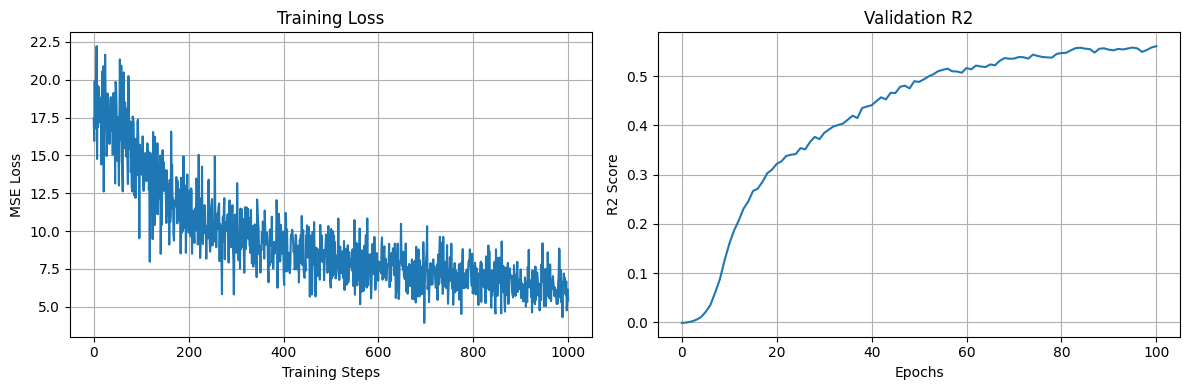

In [ ]:
seed_everything(0)

# 1. Setup datasets and dataloader
recording_id = "perich_miller_population_2018/t_20130819_center_out_reaching"
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(recording_id, batch_size=64)
num_units = len(train_dataset.get_unit_ids())
print(f"Num Units in Session: {num_units}")

# 2. Initialize Model with the new MLP definition
mlp_model = MLPNeuralDecoder(
    num_units=num_units,    # Num. of units inputted (spiking activity)
    #
    bin_size=10e-3,         # Duration (s) of bins
    sequence_length=1.0,    # Context length of the model
    #
    output_dim=2,           # Output dimension of final readout layer
    hidden_dim=32,          # Hidden dimension of the model
)
mlp_model = mlp_model.to(device)

# 3. Connect Tokenizer to Datasets
transform = mlp_model.tokenize
train_dataset.transform = transform
val_dataset.transform = transform

# 4. Setup Optimizer
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3)

# 5. Train!
mlp_r2_log, mlp_loss_log, mlp_train_outputs = train(mlp_model, optimizer, train_loader, val_loader, num_epochs=100)

# Plot the training loss and validation R2
plot_training_curves(mlp_r2_log, mlp_loss_log)


**Training Models**

2.2 Training a simple Transformer for Neural Decoding

In [ ]:
import torch.nn as nn

from torch_brain.nn import FeedForward

class TransformerNeuralDecoder(nn.Module):
    def __init__(
        self, num_units, bin_size, sequence_length,   # data properties
        dim_output, dim_hidden, n_layers, n_heads,    # transformer properties
    ):
        """Initialize the neural net components"""
        super().__init__()

        self.num_timesteps = int(sequence_length / bin_size)
        self.bin_size = bin_size

        # Create the read-in/out linear layers
        self.readin = nn.Linear(num_units, dim_hidden)
        self.readout = nn.Linear(dim_hidden, dim_output)

        # Create the position embeddings
        # Note that these are kept constant in this implementation, i.e. _not_ learnable
        self.position_embeddings = nn.Parameter(
            data=generate_sinusoidal_position_embs(self.num_timesteps, dim_hidden),
            requires_grad=False,
        )

        # Create the transformer layers:
        # each composed of the Attention and the feedforward (FFN) blocks
        self.transformer_layers = nn.ModuleList([
            nn.ModuleList([
                nn.MultiheadAttention(
                    embed_dim=dim_hidden,
                    num_heads=n_heads,
                    batch_first=True,
                ),
                FeedForward(dim=dim_hidden),
            ])
            for _ in range(n_layers)
        ])

    def forward(self, x):
        """Produces predictions from a binned spiketrain.
        This is pure PyTorch code.

        Shape of x: (B, T, N)
        """

        # Read-in: converts our input marix to transformer tokens; one token for each timestep
        x = self.readin(x)  # (B, T, N) -> (B, T, D)

        # Add position embeddings to the tokens
        x = x + self.position_embeddings[None, ...]  # -> (B, T, D)

        # Transformer
        for attn, ffn in self.transformer_layers:
            x = x + attn(x, x, x, need_weights=False)[0]
            x = x + ffn(x)

        # Readout: converts tokens to 2d vectors; each vector signifying (v_x, v_y) at that timestep
        x = self.readout(x)  # (B, T, D) -> (B, T, 2)

        return x

    def tokenize(self, data):
        # Same tokenizer as the MLP

        # A. Bin spikes
        x = bin_spikes(
            spikes=data.spikes,
            num_units=len(data.units),
            bin_size=self.bin_size,
            num_bins=self.num_timesteps,
        ).T

        # B. Extract targets
        y = data.cursor.vel

        data_dict = {
            "model_inputs": {
                "x": torch.tensor(x, dtype=torch.float32),
            },
            "target_values": torch.tensor(y, dtype=torch.float32),
        }
        return data_dict

2.2.2 Let's train!

Epoch 100/100 | Val R2 = 0.683 | Loss = 3.804
Done! Final validation R2 = 0.715


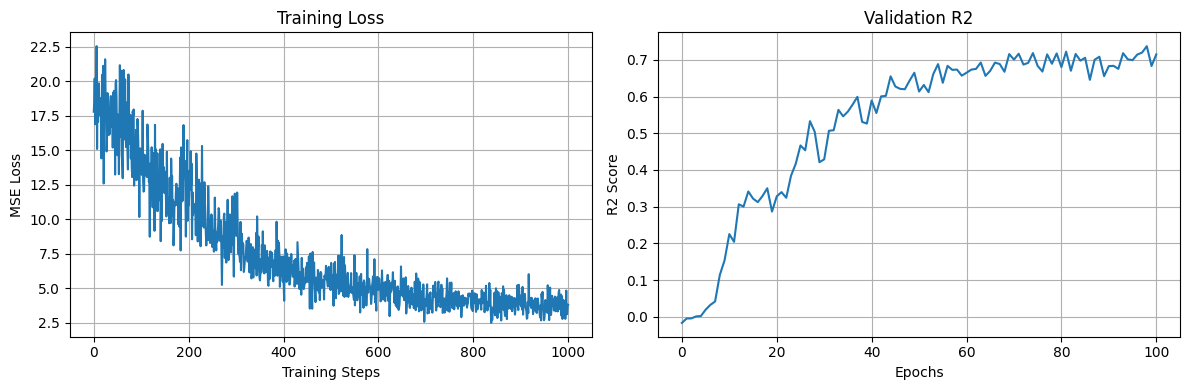

In [ ]:
seed_everything(0)

# 1. Setup datasets and dataloader
recording_id = "perich_miller_population_2018/t_20130819_center_out_reaching"
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(recording_id, batch_size=64)
num_units = len(train_dataset.get_unit_ids())

# 2. Initialize Model
tf_model = TransformerNeuralDecoder(
    num_units=num_units,    # Num. of units inputted (spiking activity)
    #
    bin_size=10e-3,         # Duration (s) of bins
    sequence_length=1.0,    # Context length of the model
    #
    dim_output=2,           # Output dimension of final readout layer
    dim_hidden=128,         # Hidden dimension of the model
    n_layers=3,             # Num. of transformer layers
    n_heads=4,              # Num. of heads in MHA blocks
).to(device)

# 3. Connect Tokenizer to Datasets
train_dataset.transform = tf_model.tokenize
val_dataset.transform = tf_model.tokenize

# 4. Setup Optimizer
optimizer = torch.optim.AdamW(tf_model.parameters(), lr=1e-3)

# 5. Train!
transformer_r2_log, transformer_loss_log, transformer_train_outputs = train(tf_model, optimizer, train_loader, val_loader, num_epochs=100)

# Plot the training loss and validation R2
plot_training_curves(transformer_r2_log, transformer_loss_log)

HOPFIELD

In [ ]:
!pip install hflayers


ERROR: Could not find a version that satisfies the requirement hflayers (from versions: none)
ERROR: No matching distribution found for hflayers


In [ ]:
!pip install git+https://github.com/ml-jku/hopfield-layers

  Cloning https://github.com/ml-jku/hopfield-layers to /tmp/pip-req-build-0ysti83k
  Running command git clone --filter=blob:none --quiet https://github.com/ml-jku/hopfield-layers /tmp/pip-req-build-0ysti83k
  Resolved https://github.com/ml-jku/hopfield-layers to commit f56f929c95b77a070ae675ea4f56b6d54d36e730
  Preparing metadata (setup.py) ... done
  Created wheel for hopfield-layers: filename=hopfield_layers-1.0.2-py3-none-any.whl size=25586 sha256=088154d98d3bbbd9a7bd093e74796302bcecc911c178c48b4cbabd163d54d643
  Stored in directory: /tmp/pip-ephem-wheel-cache-fqgcommr/wheels/32/18/8e/6a0676bf7ffad419e7ce03acf68a3b21bde9ba7659199e73f3
Successfully built hopfield-layers


Transformer+Hopfield

In [ ]:
from hflayers import Hopfield
from torch_brain.nn import FeedForward
import torch.nn as nn

class TransformerHopfieldDecoder(nn.Module):
    def __init__(
        self, num_units, bin_size, sequence_length,
        dim_output, dim_hidden, n_layers, n_heads,
    ):
        super().__init__()

        self.num_timesteps = int(sequence_length / bin_size)
        self.bin_size = bin_size

        # Read-in / Read-out
        self.readin = nn.Linear(num_units, dim_hidden)
        self.readout = nn.Linear(dim_hidden, dim_output)

        # Positional embedding
        self.position_embeddings = nn.Parameter(
            data=generate_sinusoidal_position_embs(self.num_timesteps, dim_hidden),
            requires_grad=False,
        )

        # Transformer layers
        self.transformer_layers = nn.ModuleList([
            nn.ModuleList([
                nn.MultiheadAttention(
                    embed_dim=dim_hidden,
                    num_heads=n_heads,
                    batch_first=True,
                ),
                FeedForward(dim=dim_hidden),
            ])
            for _ in range(n_layers)
        ])

        #  Hopfield layer (Only one)
        self.hopfield = Hopfield(
            input_size=dim_hidden,
            hidden_size=dim_hidden,
            output_size=dim_hidden,
            num_heads=4,
            batch_first=True
        )

    def forward(self, x):

        # Read-in
        x = self.readin(x)

        # Positional encoding
        x = x + self.position_embeddings[None, ...]

        # Transformer + Hopfield
        for i, (attn, ffn) in enumerate(self.transformer_layers):

            x = x + attn(x, x, x, need_weights=False)[0]
            if i == len(self.transformer_layers) - 1: #only last layer
              x = x + self.hopfield(x)

            x = x + ffn(x)

        # Read-out
        x = self.readout(x)

        return x

    def tokenize(self, data):

        x = bin_spikes(
            spikes=data.spikes,
            num_units=len(data.units),
            bin_size=self.bin_size,
            num_bins=self.num_timesteps,
        ).T

        y = data.cursor.vel

        return {
            "model_inputs": {
                "x": torch.tensor(x, dtype=torch.float32),
            },
            "target_values": torch.tensor(y, dtype=torch.float32),
        }

Epoch 100/100 | Val R2 = 0.731 | Loss = 3.272
Done! Final validation R2 = 0.708


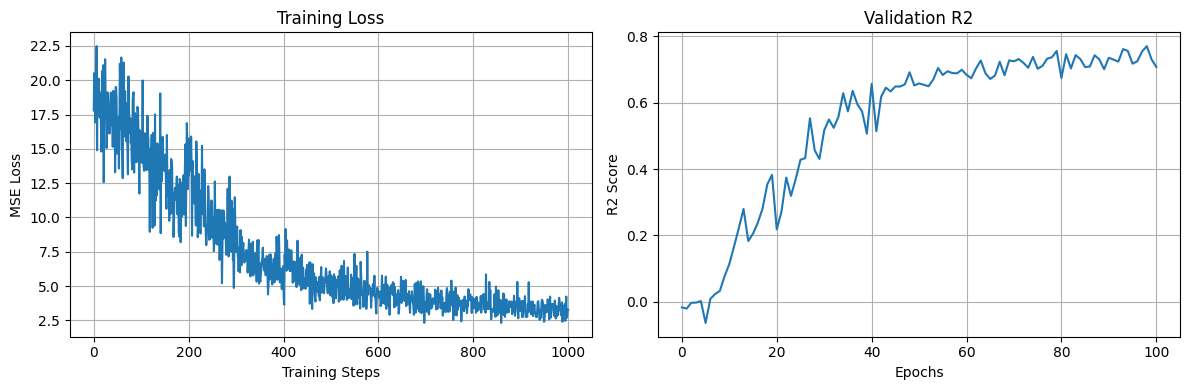

In [ ]:
seed_everything(0)

# 1. Setup datasets and dataloader
recording_id = "perich_miller_population_2018/t_20130819_center_out_reaching"
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(
    recording_id, batch_size=64
)

num_units = len(train_dataset.get_unit_ids())

# 2. Initialize Hopfield Transformer Model
hopfield_model = TransformerHopfieldDecoder(
    num_units=num_units,
    bin_size=10e-3,
    sequence_length=1.0,
    dim_output=2,
    dim_hidden=128,
    n_layers=3,
    n_heads=4,
).to(device)

# 3. Connect Tokenizer
train_dataset.transform = hopfield_model.tokenize
val_dataset.transform = hopfield_model.tokenize

# 4. Setup Optimizer
optimizer = torch.optim.AdamW(hopfield_model.parameters(), lr=1e-3)

# 5. Train
hopfield_r2_log, hopfield_loss_log, hopfield_train_outputs = train(
    hopfield_model,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=100
)

# 6. Plot
plot_training_curves(hopfield_r2_log, hopfield_loss_log)

ONLY HOPFIELD

In [ ]:
from hflayers import Hopfield
from torch_brain.nn import FeedForward
import torch
import torch.nn as nn

class HopfieldOnlyDecoder(nn.Module):
    def __init__(
        self, num_units, bin_size, sequence_length,
        dim_output, dim_hidden, n_layers
    ):
        super().__init__()

        self.num_timesteps = int(sequence_length / bin_size)
        self.bin_size = bin_size

        # Read-in / Read-out
        self.readin = nn.Linear(num_units, dim_hidden)
        self.readout = nn.Linear(dim_hidden, dim_output)

        # Position embeddings
        self.position_embeddings = nn.Parameter(
            generate_sinusoidal_position_embs(self.num_timesteps, dim_hidden),
            requires_grad=False
        )

        # Hopfield layers
        self.layers = nn.ModuleList([
            nn.ModuleList([
                Hopfield(
                    input_size=dim_hidden,
                    hidden_size=dim_hidden,
                    output_size=dim_hidden,
                    num_heads=4,
                    batch_first=True
                ),
                FeedForward(dim=dim_hidden)
            ])
            for _ in range(n_layers)
        ])

    def forward(self, x):
        # (B, T, N) → (B, T, D)
        x = self.readin(x)

        # + position
        x = x + self.position_embeddings[None, ...]

        # Hopfield blocks
        for hopfield, ffn in self.layers:
            x = x + hopfield(x)   # hopfield instead of attention
            x = x + ffn(x)

        # output
        x = self.readout(x)
        return x

    def tokenize(self, data):
        x = bin_spikes(
            spikes=data.spikes,
            num_units=len(data.units),
            bin_size=self.bin_size,
            num_bins=self.num_timesteps,
        ).T

        y = data.cursor.vel

        return {
            "model_inputs": {
                "x": torch.tensor(x, dtype=torch.float32),
            },
            "target_values": torch.tensor(y, dtype=torch.float32),
        }

Epoch 100/100 | Val R2 = 0.745 | Loss = 3.435
Done! Final validation R2 = 0.711


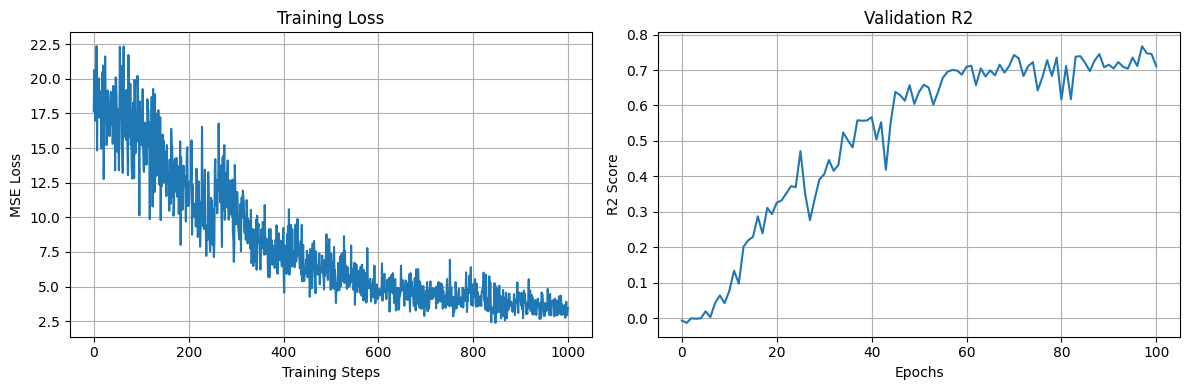

In [ ]:
seed_everything(0)

recording_id = "perich_miller_population_2018/t_20130819_center_out_reaching"
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(
    recording_id, batch_size=64
)

num_units = len(train_dataset.get_unit_ids())

hopfield_only_model = HopfieldOnlyDecoder(
    num_units=num_units,
    bin_size=10e-3,
    sequence_length=1.0,
    dim_output=2,
    dim_hidden=128,
    n_layers=3,
).to(device)

train_dataset.transform = hopfield_only_model.tokenize
val_dataset.transform = hopfield_only_model.tokenize

optimizer = torch.optim.AdamW(hopfield_only_model.parameters(), lr=1e-3)

hopfield_only_r2_log, hopfield_only_loss_log, _ = train(
    hopfield_only_model,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=100
)

plot_training_curves(hopfield_only_r2_log, hopfield_only_loss_log)

Model4

In [ ]:
from hflayers import Hopfield
from torch_brain.nn import FeedForward
import torch
import torch.nn as nn

class TransformerHopfieldDecoder_v2(nn.Module):
    def __init__(
        self, num_units, bin_size, sequence_length,
        dim_output, dim_hidden, n_layers, n_heads,
    ):
        super().__init__()

        self.num_timesteps = int(sequence_length / bin_size)
        self.bin_size = bin_size

        self.readin = nn.Linear(num_units, dim_hidden)
        self.readout = nn.Linear(dim_hidden, dim_output)

        self.position_embeddings = nn.Parameter(
            data=generate_sinusoidal_position_embs(self.num_timesteps, dim_hidden),
            requires_grad=False,
        )

        self.transformer_layers = nn.ModuleList([
            nn.ModuleList([
                nn.MultiheadAttention(
                    embed_dim=dim_hidden,
                    num_heads=n_heads,
                    batch_first=True,
                ),
                Hopfield(
                    input_size=self.num_timesteps,
                    hidden_size=self.num_timesteps,
                    output_size=self.num_timesteps,
                    num_heads=n_heads,
                    batch_first=True,
                ),
                FeedForward(dim=dim_hidden),
            ])
            for _ in range(n_layers)
        ])

    def forward(self, x):
        x = self.readin(x)                              # (B, T, N) → (B, T, D)
        x = x + self.position_embeddings[None, ...]     # + position

        for attn, hopfield, ffn in self.transformer_layers:

            # Attention: temporal relationship (T)
            x_attn = attn(x, x, x, need_weights=False)[0]  # (B, T, D)

            # Hopfield: relationship between neurons (D)
            x_hop = hopfield(
                x.transpose(1, 2)                       # (B, T, D) → (B, D, T)
            ).transpose(1, 2)                           # (B, D, T) → (B, T, D)

            x = x + x_attn + x_hop                     # combine
            x = x + ffn(x)

        x = self.readout(x)                             # (B, T, D) → (B, T, 2)
        return x

    def tokenize(self, data):
        x = bin_spikes(
            spikes=data.spikes,
            num_units=len(data.units),
            bin_size=self.bin_size,
            num_bins=self.num_timesteps,
        ).T

        y = data.cursor.vel

        return {
            "model_inputs": {
                "x": torch.tensor(x, dtype=torch.float32),
            },
            "target_values": torch.tensor(y, dtype=torch.float32),
        }

Epoch 100/100 | Val R2 = 0.691 | Loss = 1.090
Done! Final validation R2 = 0.701


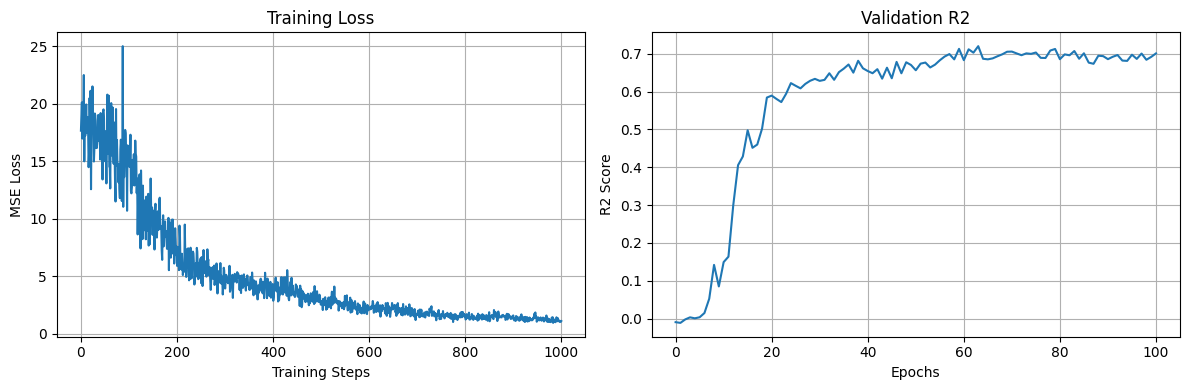

In [ ]:
seed_everything(0)

recording_id = "perich_miller_population_2018/t_20130819_center_out_reaching"
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(
    recording_id, batch_size=64
)

num_units = len(train_dataset.get_unit_ids())

tf_hop_v2_model = TransformerHopfieldDecoder_v2(
    num_units=num_units,
    bin_size=10e-3,
    sequence_length=1.0,
    dim_output=2,
    dim_hidden=128,
    n_layers=3,
    n_heads=4,
).to(device)

train_dataset.transform = tf_hop_v2_model.tokenize
val_dataset.transform = tf_hop_v2_model.tokenize

optimizer = torch.optim.AdamW(tf_hop_v2_model.parameters(), lr=1e-3)

tf_hop_v2_r2_log, tf_hop_v2_loss_log, _ = train(
    tf_hop_v2_model,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=100
)

plot_training_curves(tf_hop_v2_r2_log, tf_hop_v2_loss_log)

In [ ]:
import torch
import os

os.makedirs("/content/drive/MyDrive/saved_models", exist_ok=True)

torch.save(mlp_model.state_dict(),           "/content/drive/MyDrive/saved_models/mlp_model.pth")
torch.save(tf_model.state_dict(),            "/content/drive/MyDrive/saved_models/transformer_model.pth")
torch.save(hopfield_model.state_dict(),      "/content/drive/MyDrive/saved_models/transformer_hopfield_model.pth")
torch.save(hopfield_only_model.state_dict(), "/content/drive/MyDrive/saved_models/hopfield_only_model.pth")
torch.save(tf_hop_v2_model.state_dict(),     "/content/drive/MyDrive/saved_models/transformer_hopfield_v2_model.pth")

print("Models are saved!")

Models are saved!


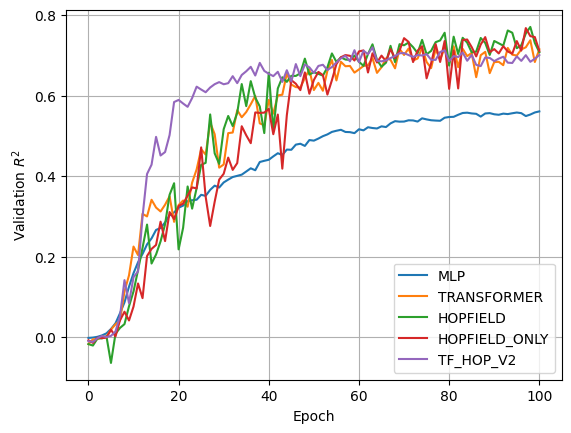

In [ ]:
lcls = locals().copy()
for lcl in lcls:
    if not lcl.endswith("_r2_log"):
        continue
    model = lcl.split("_r2_log")[0].upper()
    plt.plot(locals()[lcl], label=model)
plt.xlabel("Epoch")
plt.ylabel("Validation $R^2$")
plt.grid()
plt.legend()
plt.show()